#Load Dataset


In [3]:
import numpy as np
import pandas as pd

In [4]:
df = pd.read_csv('House_Price.csv', usecols=['Location', 'BHK', 'Total_Sq.ft', 'Flat_Price'])

In [5]:
df.head()

,Flat_Price,BHK,Location,Total_Sq.ft
0,₹8.5 Cr,6 BHK,"Ballygunge, Kolkata",4200 sq.ft
1,₹45.0 L,3 BHK,"Barrackpore, Kolkata",1400 sq.ft
2,₹1.35 Cr,3 BHK,"Santoshpur, Kolkata",2500 sq.ft
3,₹60.0 L,5 BHK,"Sarsuna, Kolkata",1100 sq.ft
4,₹52.0 L,4 BHK,"Madhyamgram, Kolkata",900 sq.ft


In [6]:
df.shape

(3968, 4)

##Handle Missing Values


In [7]:
df.isnull().sum()

Flat_Price     0
BHK            0
Location       2
Total_Sq.ft    0
dtype: int64

In [8]:
df = df.dropna(subset=['Location'])

df.shape

(3966, 4)

In [9]:
df.isnull().sum()

Flat_Price     0
BHK            0
Location       0
Total_Sq.ft    0
dtype: int64

##Handle BHK column


In [10]:
df['BHK'].unique()

array(['6 BHK', '3 BHK', '5 BHK', '4 BHK', '2 BHK', '9 BHK', '10 BHK',
       '7 BHK', '8 BHK', '1 RK', '1 BHK', '2 RK', '10.5 BHK', '3.5 BHK',
       '2.5 BHK', '8.5 BHK', '2 BH', '6 RK'], dtype=object)

In [11]:
df['BHK'] =  [float(item.split()[0]) for item in df['BHK']]

In [12]:
df.head(10)

,Flat_Price,BHK,Location,Total_Sq.ft
0,₹8.5 Cr,6.0,"Ballygunge, Kolkata",4200 sq.ft
1,₹45.0 L,3.0,"Barrackpore, Kolkata",1400 sq.ft
2,₹1.35 Cr,3.0,"Santoshpur, Kolkata",2500 sq.ft
3,₹60.0 L,5.0,"Sarsuna, Kolkata",1100 sq.ft
4,₹52.0 L,4.0,"Madhyamgram, Kolkata",900 sq.ft
5,₹32.0 L,3.0,"Thakurpukur, Kolkata",1200 sq.ft
6,₹69.3 L,3.0,"Rajpur, Kolkata",2310 sq.ft
7,₹40.0 L,2.0,"North Dum Dum, Kolkata",1170 sq.ft
8,₹95.0 L,4.0,"Dhakuria, Kolkata",1862 sq.ft
9,₹3.0 Cr,9.0,"Shyambazar, Kolkata",4200 sq.ft


In [13]:
df['BHK'].unique()

array([ 6. ,  3. ,  5. ,  4. ,  2. ,  9. , 10. ,  7. ,  8. ,  1. , 10.5,
        3.5,  2.5,  8.5])

##Handle Total Square FT Column


In [14]:
df['Total_Sq.ft'] =  [float(item.split()[0]) for item in df['Total_Sq.ft']]

In [15]:
df.head(3)

,Flat_Price,BHK,Location,Total_Sq.ft
0,₹8.5 Cr,6.0,"Ballygunge, Kolkata",4200.0
1,₹45.0 L,3.0,"Barrackpore, Kolkata",1400.0
2,₹1.35 Cr,3.0,"Santoshpur, Kolkata",2500.0


In [16]:
df['Total_Sq.ft'].describe()

count     3966.000000
mean      2649.569339
std       2375.171913
min        150.000000
25%       1250.000000
50%       2000.000000
75%       3000.000000
max      32000.000000
Name: Total_Sq.ft, dtype: float64

In [17]:
df['Total_Sq.ft'].info()

<class 'pandas.core.series.Series'>
Index: 3966 entries, 0 to 3967
Series name: Total_Sq.ft
Non-Null Count  Dtype  
--------------  -----  
3966 non-null   float64
dtypes: float64(1)
memory usage: 62.0 KB


##Handle Location


In [18]:
df['Location'].nunique()

201

In [19]:
df['Location'] = df['Location'].str.replace(", Kolkata", "").str.rstrip(',').str.strip()

In [20]:
df.head()

,Flat_Price,BHK,Location,Total_Sq.ft
0,₹8.5 Cr,6.0,Ballygunge,4200.0
1,₹45.0 L,3.0,Barrackpore,1400.0
2,₹1.35 Cr,3.0,Santoshpur,2500.0
3,₹60.0 L,5.0,Sarsuna,1100.0
4,₹52.0 L,4.0,Madhyamgram,900.0


In [21]:
df['Location'].nunique()

201

In [22]:
df['Location'].info()

<class 'pandas.core.series.Series'>
Index: 3966 entries, 0 to 3967
Series name: Location
Non-Null Count  Dtype 
--------------  ----- 
3966 non-null   object
dtypes: object(1)
memory usage: 62.0+ KB


In [23]:
df['Location'].unique()

array(['Ballygunge', 'Barrackpore', 'Santoshpur', 'Sarsuna',
       'Madhyamgram', 'Thakurpukur', 'Rajpur', 'North Dum Dum',
       'Dhakuria', 'Shyambazar', 'Nazirabad', 'Joka', 'Kasba', 'Barisha',
       'Behala', 'Taratala', 'Jodhpur Park', 'Salt Lake City', 'New Town',
       'Mohispota', 'Maheshtala', 'Naihati', 'Birati', 'Amtala',
       'Gariahat', 'New Barrakpur', 'Rajpur Sonarpur', 'Khardah',
       'Belghoria', 'Sodepur', 'Baghbazar', 'Baghajatin', 'Nimta',
       'Lake Gardens', 'Khidirpur', 'Kolutolla', 'Baguiati',
       'Diamond Harbour', 'Bantala', 'Tollygunge', 'Sinthi', 'Beliaghata',
       'Kamardanga', 'Netaji Nagar', 'Garia', 'Rajarhat', 'Kalikapur',
       'East Kolkata Township', 'Tangra', 'Bhowanipore', 'Bansdroni',
       'Kalighat', 'Ichapur', 'Mukundapur', 'Bramhapur', 'Hussainpur',
       'Berunanpukhuria', 'Kolkata', 'Bhatpara', 'Keshtopur',
       'Chinar Park', 'Baguihati', 'New Alipore', 'Kamdahari',
       'Paschim Putiary', 'Ganguly Bagan', 'Kaikhali', 

##Handling Flat Price Column


In [24]:
def clean_price_column(price):
    price = price.replace("₹", "").strip()

    if "Cr" in price:
        price = float(price.replace(" Cr", "").strip())

    elif "L" in price:
        price = float(price.replace("₹", "").strip().replace(" L", "")) /100

    else:
        price = float(price)

    return price


In [25]:
df['Flat_Price'] = df['Flat_Price'].apply(clean_price_column)

In [26]:
df.head(10)

,Flat_Price,BHK,Location,Total_Sq.ft
0,8.500,6.0,Ballygunge,4200.0
1,0.450,3.0,Barrackpore,1400.0
2,1.350,3.0,Santoshpur,2500.0
3,0.600,5.0,Sarsuna,1100.0
4,0.520,4.0,Madhyamgram,900.0
5,0.320,3.0,Thakurpukur,1200.0
6,0.693,3.0,Rajpur,2310.0
7,0.400,2.0,North Dum Dum,1170.0
8,0.950,4.0,Dhakuria,1862.0
9,3.000,9.0,Shyambazar,4200.0


#Outliers: Detect and Remove


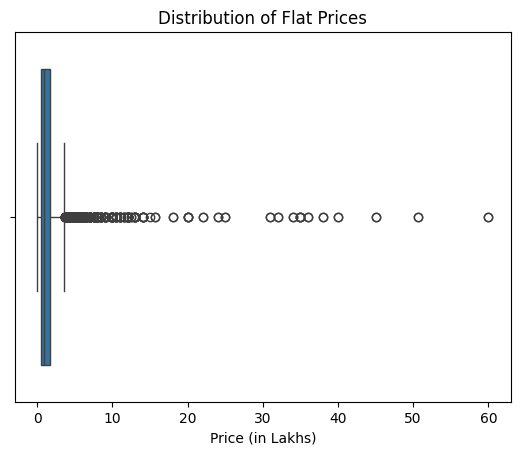

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Box plot for Price
sns.boxplot(x=df['Flat_Price'])
plt.title('Distribution of Flat Prices')
plt.xlabel('Price (in Lakhs)')
plt.show()

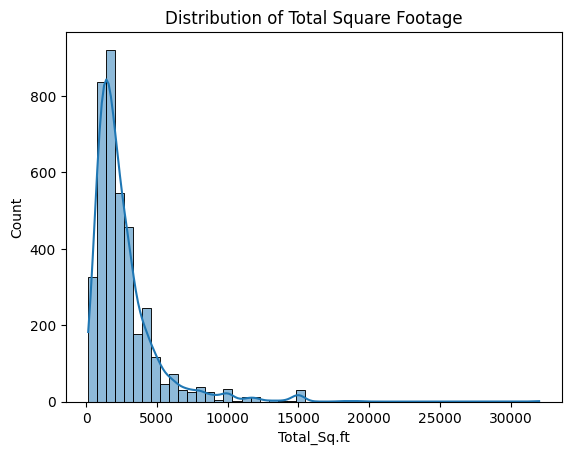

In [28]:
sns.histplot(df['Total_Sq.ft'], kde=True, bins=50)
plt.title('Distribution of Total Square Footage')
plt.show()

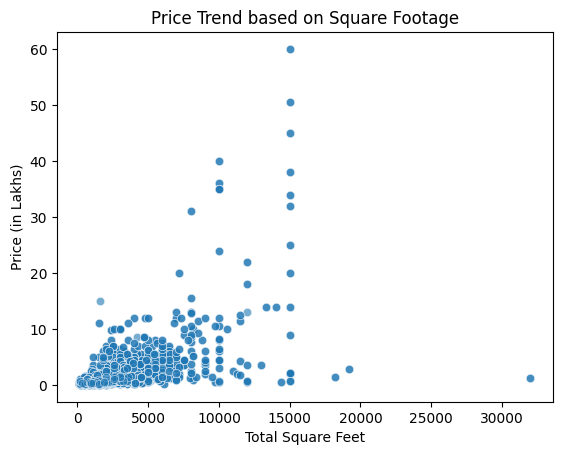

In [29]:
sns.scatterplot(x='Total_Sq.ft', y='Flat_Price', data=df, alpha=0.6)
plt.title('Price Trend based on Square Footage')
plt.xlabel('Total Square Feet')
plt.ylabel('Price (in Lakhs)')
plt.show()

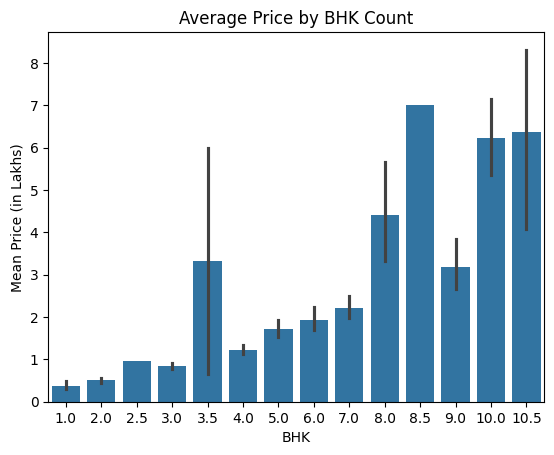

In [30]:
sns.barplot(x='BHK', y='Flat_Price', data=df, estimator=np.mean)
plt.title('Average Price by BHK Count')
plt.ylabel('Mean Price (in Lakhs)')
plt.show()

C:\Users\Biswajit\AppData\Local\Temp\ipykernel_25356\1930183856.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_locations.values, y=top_locations.index, palette='viridis')


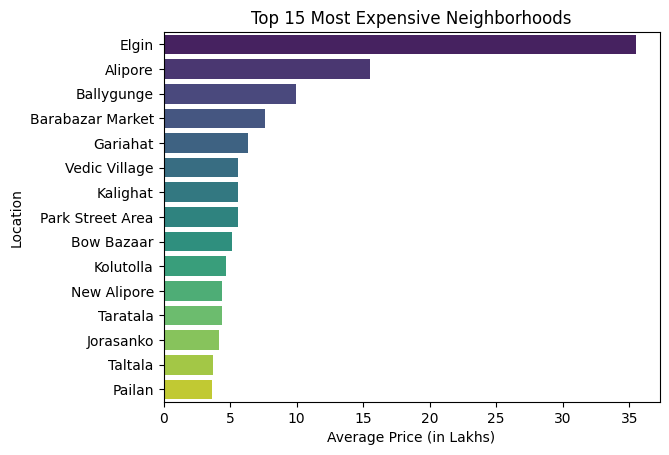

In [31]:
top_locations = df.groupby('Location')['Flat_Price'].mean().sort_values(ascending=False).head(15)

sns.barplot(x=top_locations.values, y=top_locations.index, palette='viridis')
plt.title('Top 15 Most Expensive Neighborhoods')
plt.xlabel('Average Price (in Lakhs)')
plt.show()

We will use implicit ratio of $\frac{\text{Total_Sq.ft}}{\text{BHK}}$ and use a threshold value of 120 sq ft


In [32]:
initial_rows = len(df)

df = df[(df['Total_Sq.ft'] / df['BHK']) >= 250]

final_rows = len(df)
removed_rows = initial_rows - final_rows

print("--- SIZE-PER-BHK FILTER COMPLETE ---")
print(f"Rows before filtering: {initial_rows}")
print(f"Rows after filtering:  {final_rows}")
print(f"Impossible anomaly rows removed: {removed_rows}")

--- SIZE-PER-BHK FILTER COMPLETE ---
Rows before filtering: 3966
Rows after filtering:  3668
Impossible anomaly rows removed: 298


In [33]:
df.describe()

,Flat_Price,BHK,Total_Sq.ft
count,3668.000000,3668.000000,3668.000000
mean,1.884704,4.697519,2781.741821
std,3.792165,2.424629,2417.261256
min,0.013500,1.000000,250.000000
25%,0.500000,3.000000,1400.000000
50%,0.900000,4.000000,2100.000000
75%,1.800000,6.000000,3200.000000
max,60.000000,10.500000,32000.000000


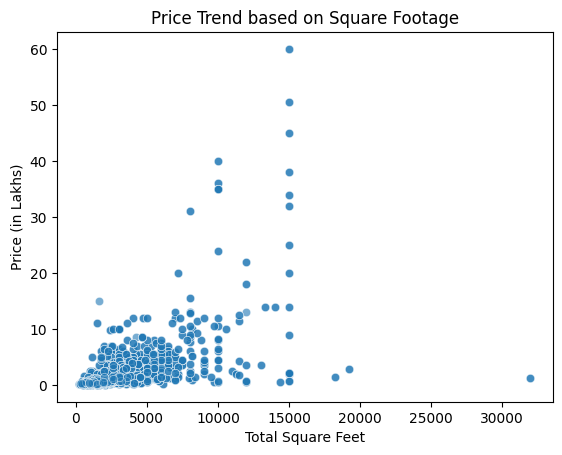

In [34]:
sns.scatterplot(x='Total_Sq.ft', y='Flat_Price', data=df, alpha=0.6)
plt.title('Price Trend based on Square Footage')
plt.xlabel('Total Square Feet')
plt.ylabel('Price (in Lakhs)')
plt.show()

In [35]:
import pandas as pd

df['Price_per_Sqft'] = (df['Flat_Price'] * 100000) / df['Total_Sq.ft']

cleaned_chunks = []

for location, sub_df in df.groupby('Location'):
    if len(sub_df) <= 5:
        cleaned_chunks.append(sub_df)
        continue

    local_mean = sub_df['Price_per_Sqft'].mean()
    local_std = sub_df['Price_per_Sqft'].std()

    lower_limit = local_mean - (2 * local_std)
    upper_limit = local_mean + (2 * local_std)

    filtered_sub_df = sub_df[(sub_df['Price_per_Sqft'] >= lower_limit) & (sub_df['Price_per_Sqft'] <= upper_limit)]
    cleaned_chunks.append(filtered_sub_df)

df_cleaned = pd.concat(cleaned_chunks, ignore_index=True)

df_cleaned = df_cleaned.drop(columns=['Price_per_Sqft'])

print("--- CONTEXTUAL PRICE FILTER COMPLETE ---")
print(f"Rows remaining after price outlier removal: {len(df_cleaned)}")

--- CONTEXTUAL PRICE FILTER COMPLETE ---
Rows remaining after price outlier removal: 3501


In [36]:
df_cleaned.describe()

,Flat_Price,BHK,Total_Sq.ft
count,3501.000000,3501.000000,3501.000000
mean,1.711684,4.690803,2776.232219
std,3.216749,2.415104,2373.787307
min,0.013500,1.000000,250.000000
25%,0.480000,3.000000,1400.000000
50%,0.850000,4.000000,2100.000000
75%,1.700000,6.000000,3240.000000
max,50.600000,10.500000,32000.000000


In [37]:
df_cleaned.shape

(3501, 4)

In [38]:
# 1. Record row count before dropping the mega-outlier
rows_before_cap = len(df_cleaned)

# 2. Filter the DataFrame to keep only properties under 10,000 sq.ft.
df_cleaned = df_cleaned[df_cleaned['Total_Sq.ft'] <= 17000]

# 3. Verify the new maximum size and rows removed
rows_after_cap = len(df_cleaned)
print("--- MAXIMUM SIZE CAP COMPLETE ---")
print(f"Rows removed: {rows_before_cap - rows_after_cap}")
print(f"New maximum square footage in dataset: {df_cleaned['Total_Sq.ft'].max()} sq.ft.")

--- MAXIMUM SIZE CAP COMPLETE ---
Rows removed: 6
New maximum square footage in dataset: 15000.0 sq.ft.


In [39]:
df_cleaned.describe()

,Flat_Price,BHK,Total_Sq.ft
count,3495.000000,3495.000000,3495.000000
mean,1.711435,4.687983,2741.267811
std,3.219384,2.413293,2205.306701
min,0.013500,1.000000,250.000000
25%,0.480000,3.000000,1400.000000
50%,0.850000,4.000000,2100.000000
75%,1.700000,6.000000,3200.000000
max,50.600000,10.500000,15000.000000


Text(0, 0.5, 'Flat Price (in Crores)')

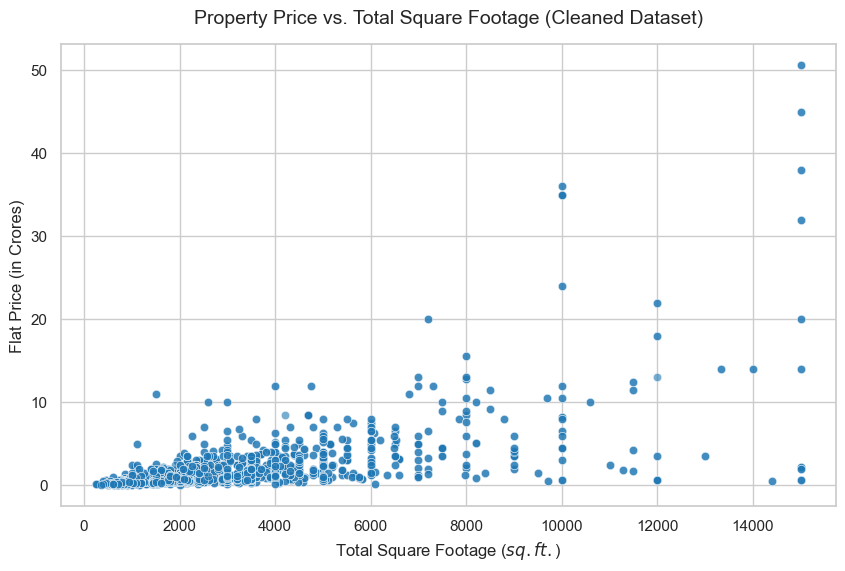

In [40]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 2. Generate the scatterplot using the cleaned DataFrame
sns.scatterplot(
    x='Total_Sq.ft',
    y='Flat_Price',
    data=df_cleaned,
    alpha=0.6,          # Adds transparency to see overlapping data points clearly
    color='#1f77b4',    # Standard professional blue tone
    edgecolor='w'       # White borders around dots for better contrast
)

# 3. Apply titles and labels
plt.title('Property Price vs. Total Square Footage (Cleaned Dataset)', fontsize=14, pad=15)
plt.xlabel('Total Square Footage ($sq.ft.$)', fontsize=12)
plt.ylabel('Flat Price (in Crores)', fontsize=12)

In [41]:
df_cleaned.shape

(3495, 4)

In [42]:
df_cleaned.tail(10)

,Flat_Price,BHK,Location,Total_Sq.ft
3491,0.25,2.0,Vedic Village,1440.0
3492,0.25,2.0,Vedic Village,1440.0
3493,0.40,4.0,Ward No 113,1500.0
3494,0.40,4.0,Ward No 113,1500.0
3495,0.13,2.0,Ward No 113,600.0
3496,0.13,2.0,Ward No 113,600.0
3497,0.33,4.0,Ward No 113,1620.0
3498,0.33,4.0,Ward No 113,1620.0
3499,0.45,2.0,Ward No 113,950.0
3500,0.45,2.0,Ward No 113,950.0


#One Hot Encoding


##Train Test Split


In [43]:
X = df_cleaned[['Total_Sq.ft', 'BHK', 'Location']]
y = df_cleaned['Flat_Price']

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


##Column Transformer Pipeline


In [45]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['Location'])
    ],
    remainder='passthrough'
)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape:  {X_test.shape}")

Training features shape: (2796, 3)
Testing features shape:  (699, 3)


#Model Selection


In [46]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor

from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

##Linear Regression


In [47]:
lr_pipeline = Pipeline(steps = [
                        ('preprocessor', preprocessor),
                        ('regressor', LinearRegression())
                    ])

In [48]:
lr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](3,)","['Total_Sq.ft','BHK','Location']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,3
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers

In [49]:
lr_y_preds = lr_pipeline.predict(X_test)

In [50]:
lr_mae_score = mean_squared_error(y_test, lr_y_preds)
lr_r2_score = r2_score(y_test, lr_y_preds)

print(f"Mean Absolute Error: {lr_mae_score}")
print(f"R2 Score: {lr_r2_score}")

Mean Absolute Error: 3.6379692933137324
R2 Score: 0.7146390393665536


##Random Forest Regressor


In [51]:
random_forest = RandomForestRegressor(
    n_estimators=125,
    random_state=42,
    n_jobs = -1
)

In [52]:
rf_pipeline = Pipeline(steps = [
                        ('preprocessor', preprocessor),
                        ('regressor', random_forest)
                    ])

In [53]:
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](3,)","['Total_Sq.ft','BHK','Location']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,3
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers

In [54]:
rf_y_preds = rf_pipeline.predict(X_test)

In [55]:
rf_mae_score = mean_squared_error(y_test, rf_y_preds)
rf_r2_score = r2_score(y_test, rf_y_preds)

print(f"Mean Absolute Error: {rf_mae_score}")
print(f"R2 Score: {rf_r2_score}")

Mean Absolute Error: 1.6949575345986578
R2 Score: 0.8670481603033531


##Extra Trees Regressor


In [56]:
etr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', ExtraTreesRegressor(n_estimators=180,
                                      random_state=42,
                                      n_jobs=-1))
])

etr_pipeline.fit(X_train, y_train)
etr_preds = etr_pipeline.predict(X_test)

etr_mae_score = mean_squared_error(y_test, etr_preds)
etr_r2_score = r2_score(y_test, etr_preds)

In [57]:
print(f"Mean Absolute Error: {etr_mae_score}")
print(f"R2 Score: {etr_r2_score}")

Mean Absolute Error: 0.6377668049127305
R2 Score: 0.9499738086177613


#Custom Simulation


In [58]:
def predict_real_world_price(sqft, bhk, location_name):
    """
    Takes plain raw variables directly from a user interface, formats them
    into a structured row DataFrame, and handles the encoding/prediction automatically.
    """
    custom_input = pd.DataFrame([{
        'Total_Sq.ft': float(sqft),
        'BHK': float(bhk),
        'Location': str(location_name)
    }])

    predicted_price = etr_pipeline.predict(custom_input)[0]
    return predicted_price

sample = predict_real_world_price(sqft=1600, bhk=3, location_name='Tollygunge')

print(f"Input: 1600 sq.ft, 3 BHK, Location: Tollygunge")
print(f"Prediction: {sample:.2f} Crores")

Input: 1600 sq.ft, 3 BHK, Location: Tollygunge
Prediction: 0.64 Crores


#Saving our Model


In [59]:
import pandas as pd
import pickle
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import ExtraTreesRegressor

X_production = df_cleaned[['Total_Sq.ft', 'BHK', 'Location']]
y_production = df_cleaned['Flat_Price']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['Location'])
    ],
    remainder='passthrough'
)

production_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', ExtraTreesRegressor(n_estimators=180,
                                      random_state=42,
                                      n_jobs=-1))
])

production_pipeline.fit(X_production, y_production)

model_filename = 'final_production_model.pkl'

with open(model_filename, 'wb') as file:
    pickle.dump(production_pipeline, file)

print(f"Your unified pipeline has been saved as: {model_filename}")
print("This file contains the text encoder AND the machine learning model.")

Your unified pipeline has been saved as: final_production_model.pkl
This file contains the text encoder AND the machine learning model.


In [60]:
import pickle
import pandas as pd

with open('final_production_model.pkl', 'rb') as file:
    loaded_pipeline = pickle.load(file)

incoming_data = pd.DataFrame([{
    'Total_Sq.ft': 1600.0,
    'BHK': 3.0,
    'Location': 'Tollygunge'
}])

predicted_valuation = loaded_pipeline.predict(incoming_data)[0]
print(f"Live Web App Output: {predicted_valuation:.2f} Crores")

Live Web App Output: 0.65 Crores


In [61]:
# from google.colab import files

# model_filename = 'final_production_model.pkl'

# print(f"Downloading {model_filename}...")

# files.download(model_filename)